In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.columns = [
    'row_number', 'customer_id', 'surname', 'credit_score',
    'country', 'gender', 'age', 'tenure', 'balance',
    'products_number', 'credit_card', 'active_member',
    'estimated_salary', 'churn'
]

df.head()

,row_number,customer_id,surname,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print(df.info())
print(df.describe(include='all').T)

print(df.isnull().sum())

print(df['churn'].value_counts())
print(df['churn'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   row_number        10000 non-null  int64  
 1   customer_id       10000 non-null  int64  
 2   surname           10000 non-null  object 
 3   credit_score      10000 non-null  int64  
 4   country           10000 non-null  object 
 5   gender            10000 non-null  object 
 6   age               10000 non-null  int64  
 7   tenure            10000 non-null  int64  
 8   balance           10000 non-null  float64
 9   products_number   10000 non-null  int64  
 10  credit_card       10000 non-null  int64  
 11  active_member     10000 non-null  int64  
 12  estimated_salary  10000 non-null  float64
 13  churn             10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
                    count unique     top  freq           mean           s

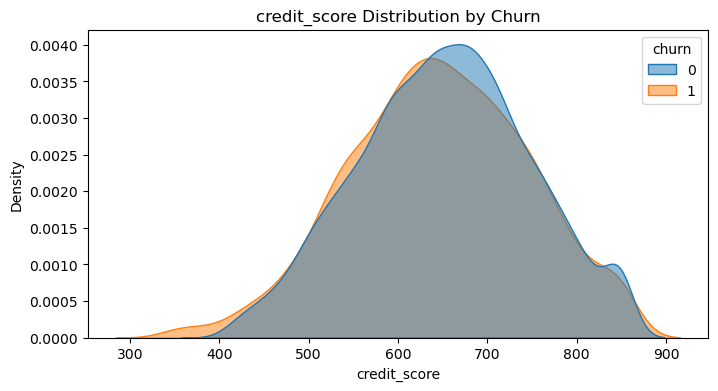

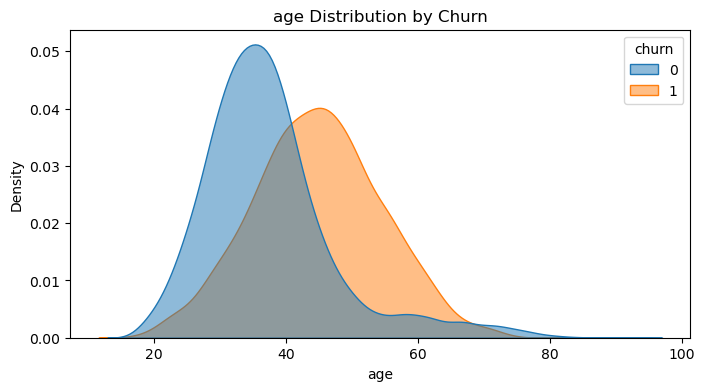

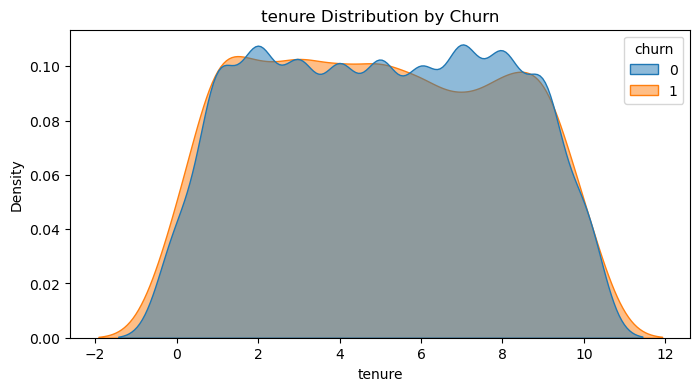

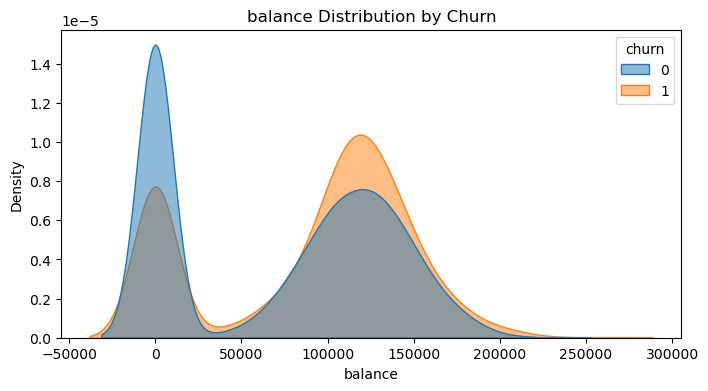

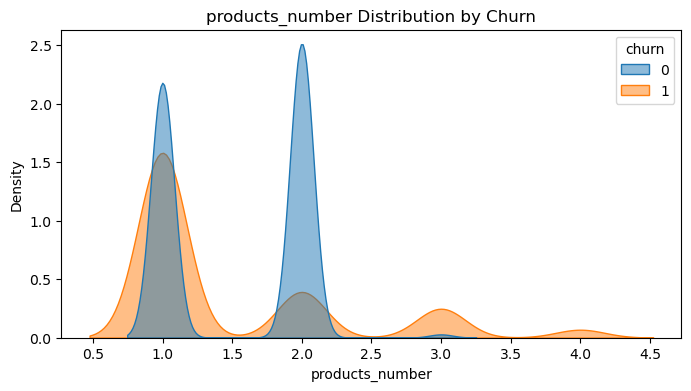

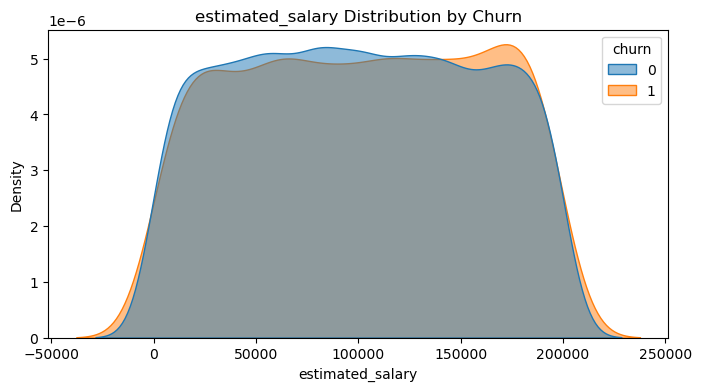

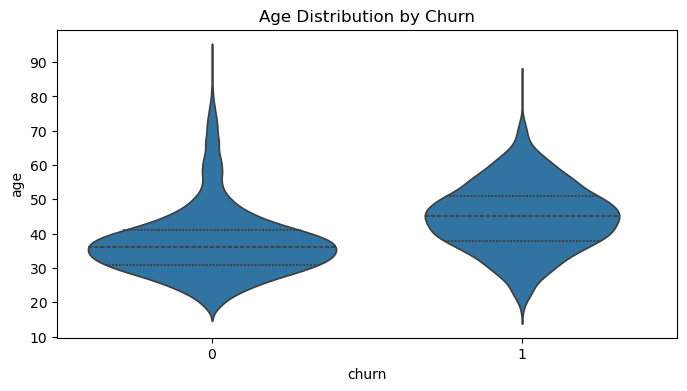

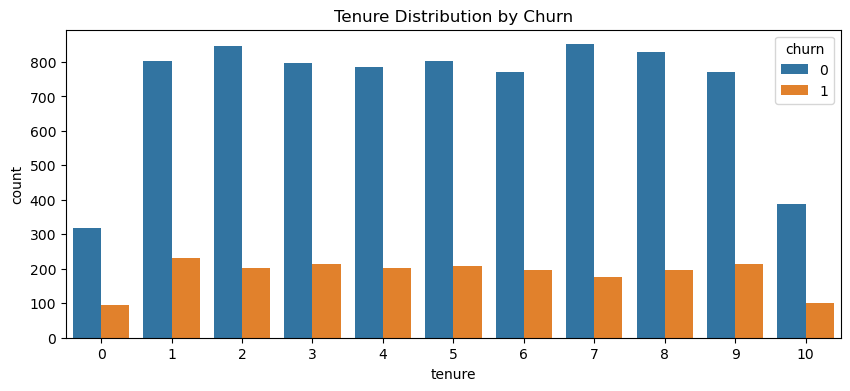

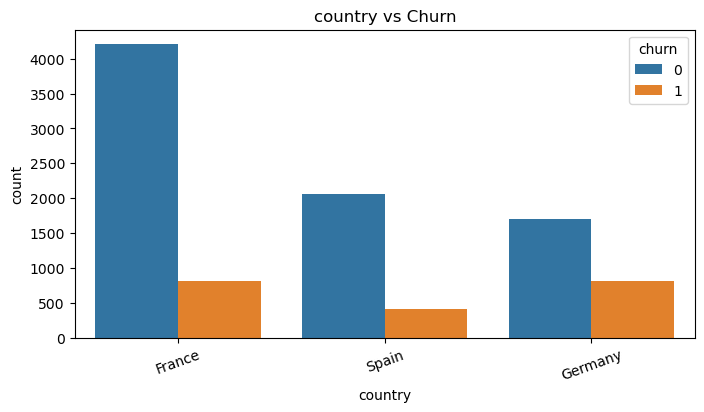

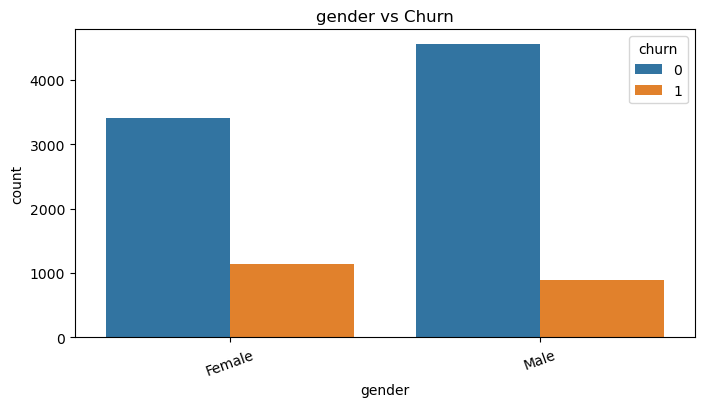

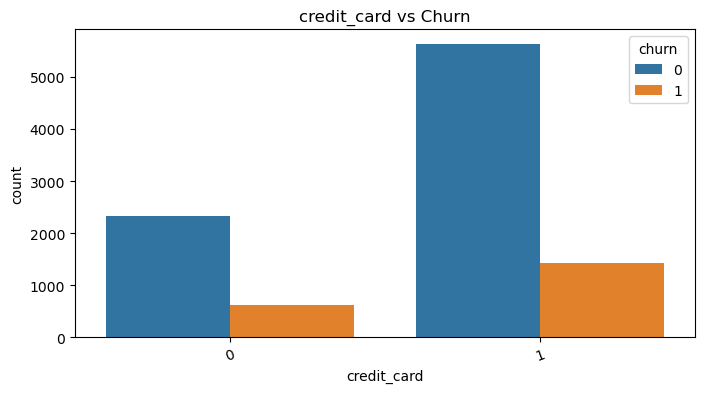

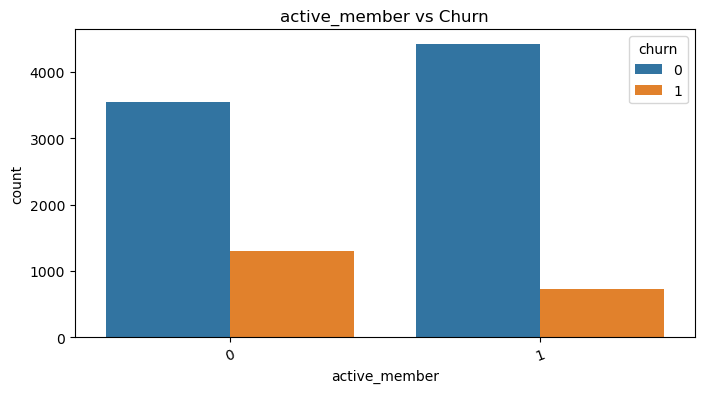

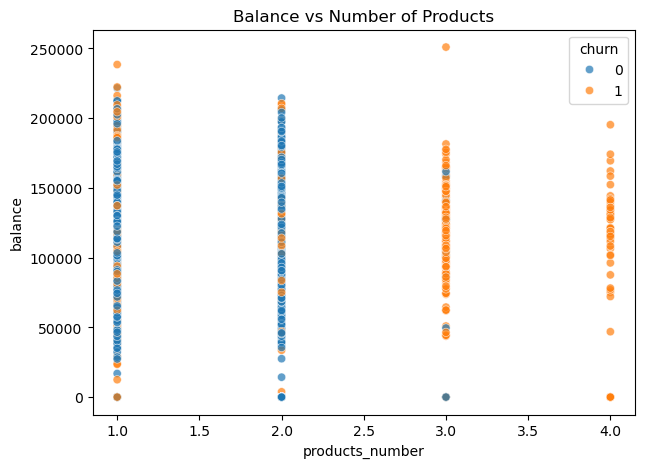

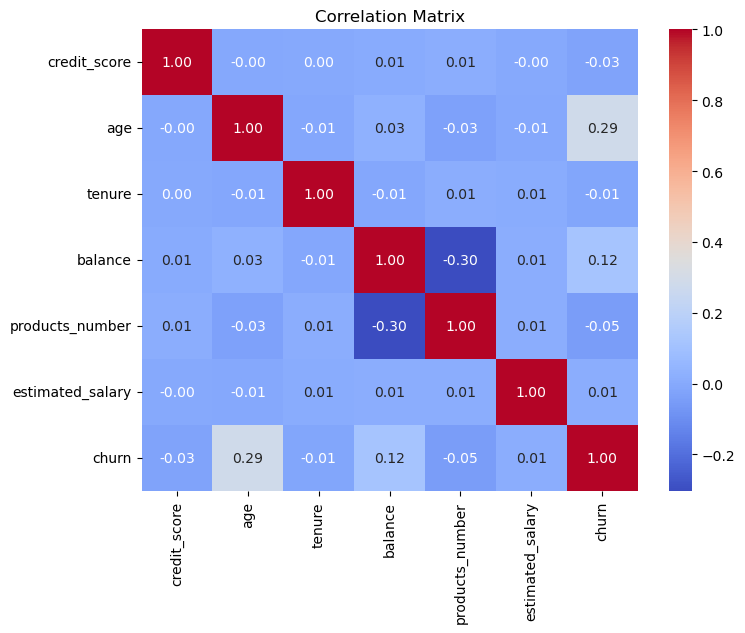

In [5]:
num_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.kdeplot(data=df, x=col, hue='churn', fill=True, common_norm=False, alpha=0.5)
    plt.title(f'{col} Distribution by Churn')
    plt.show()

plt.figure(figsize=(8,4))
sns.violinplot(data=df, x='churn', y='age', inner='quart')
plt.title('Age Distribution by Churn')
plt.show()

plt.figure(figsize=(10,4))
sns.countplot(data=df, x='tenure', hue='churn')
plt.title('Tenure Distribution by Churn')
plt.show()



cat_cols = ['country', 'gender', 'credit_card', 'active_member']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue='churn')
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=20)
    plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='products_number', y='balance', hue='churn', alpha=0.7)
plt.title('Balance vs Number of Products')
plt.show()

corr = df[num_cols + ['churn']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [6]:

df_fe = df.copy()

df_fe['balance_per_product'] = df_fe['balance'] / df_fe['products_number'].replace(0, np.nan)
df_fe['balance_per_product'] = df_fe['balance_per_product'].fillna(0)

df_fe['salary_balance_ratio'] = df_fe['estimated_salary'] / df_fe['balance'].replace(0, np.nan)
df_fe['salary_balance_ratio'] = df_fe['salary_balance_ratio'].replace([np.inf, -np.inf], np.nan)
df_fe['salary_balance_ratio'] = df_fe['salary_balance_ratio'].fillna(df_fe['salary_balance_ratio'].median())

bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']

df_fe['age_group'] = pd.cut(df_fe['age'], bins=bins, labels=labels)

df_fe['tenure_bucket'] = pd.cut(
    df_fe['tenure'],
    bins=[-1, 0, 2, 5, 10],
    labels=['0', '1-2', '3-5', '6-10']
)

df_fe['high_balance'] = (df_fe['balance'] > df_fe['balance'].quantile(0.75)).astype(int)

In [7]:
target = 'churn'

drop_cols = ['row_number', 'customer_id', 'surname', 'churn']

X = df_fe.drop(columns=drop_cols)
y = df_fe[target]

numeric_features = [
    'credit_score', 'age', 'tenure', 'balance',
    'products_number', 'estimated_salary',
    'balance_per_product', 'salary_balance_ratio'
]

categorical_features = [
    'country', 'gender', 'credit_card',
    'active_member', 'age_group',
    'tenure_bucket', 'high_balance'
]

In [8]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])



preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 15)
(2000, 15)


In [10]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=500),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    'SVC': SVC(probability=True, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    results[name] = scores
    print(f'{name}: Mean AUC = {scores.mean():.4f}')

LogisticRegression: Mean AUC = 0.7877
RandomForest: Mean AUC = 0.8486
GradientBoosting: Mean AUC = 0.8628
AdaBoost: Mean AUC = 0.8428
SVC: Mean AUC = 0.8351


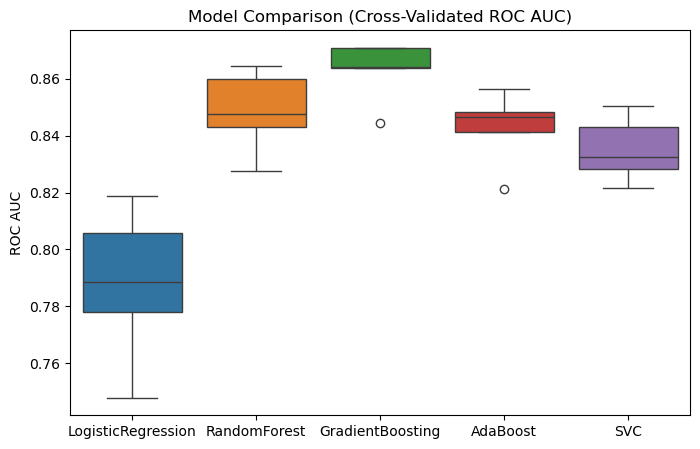

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(data=list(results.values()))
plt.xticks(range(len(results)), list(results.keys()))
plt.ylabel('ROC AUC')
plt.title('Model Comparison (Cross-Validated ROC AUC)')
plt.show()

In [12]:
# Choose best model (automatic pick by mean AUC)
best_name = max(results.keys(), key=lambda k: results[k].mean())
best_name, results[best_name].mean()

('GradientBoosting', 0.8627777349731776)

Test Accuracy: 0.8680
Test Precision: 0.7804
Test Recall: 0.4889
Test F1-score: 0.6012
Test ROC AUC: 0.8692

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.78      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



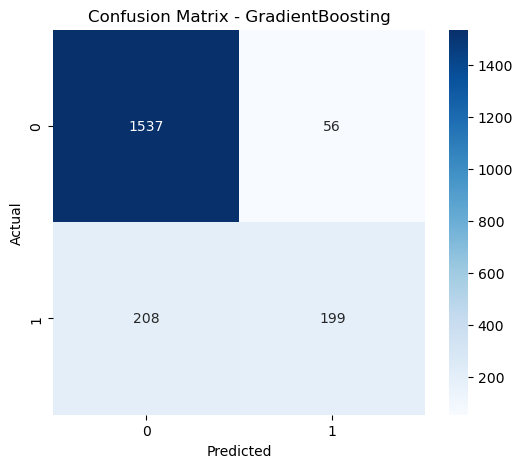

In [13]:
# Final evaluation of best model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

best_model = models[best_name]

best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

best_pipeline.fit(X_train, y_train)

# Predictions
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall: {rec:.4f}")
print(f"Test F1-score: {f1:.4f}")
print(f"Test ROC AUC: {roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')

plt.show()

age                     0.327665
products_number         0.266459
balance_per_product     0.063396
balance                 0.056953
active_member_0         0.052653
country_Germany         0.050689
active_member_1         0.047992
salary_balance_ratio    0.029992
estimated_salary        0.025547
credit_score            0.022685
age_group_45-54         0.020634
age_group_55-64         0.007968
gender_Female           0.006850
gender_Male             0.006532
tenure                  0.005683
country_France          0.003164
tenure_bucket_3-5       0.001564
age_group_35-44         0.001415
credit_card_1           0.000697
country_Spain           0.000577
dtype: float64

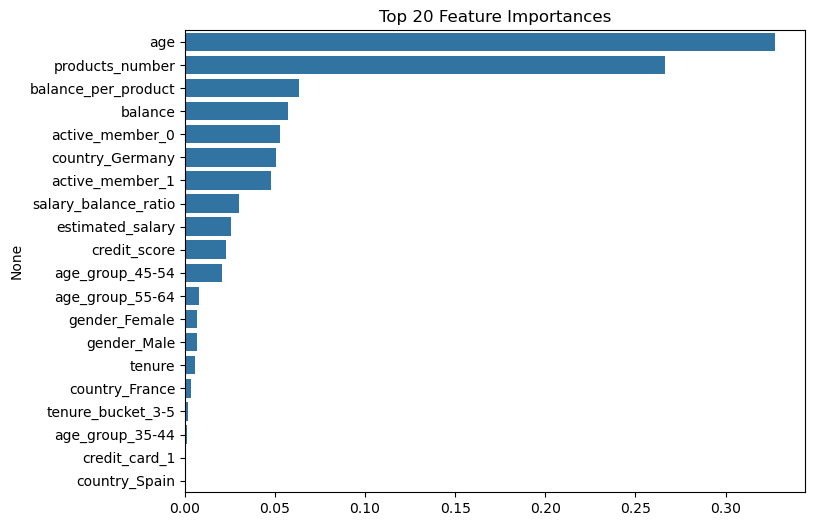

In [14]:
if hasattr(best_pipeline.named_steps['classifier'], 'feature_importances_'):
    num_feats = numeric_features
    cat_feats = list(best_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features))
    feature_names = num_feats + cat_feats
    importances = best_pipeline.named_steps['classifier'].feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:20]
    display(fi)
    plt.figure(figsize=(8,6))
    sns.barplot(x=fi.values, y=fi.index)
    plt.title('Top 20 Feature Importances')
    plt.show()
else:
    print('Selected model does not provide feature_importances_ attribute.')

In [15]:
# Step 11. Save the best pipeline

import joblib

joblib.dump(best_pipeline, 'best_churn_pipeline.pkl')

print("Saved pipeline: best_churn_pipeline.pkl")

Saved pipeline: best_churn_pipeline.pkl


In [16]:
# Step 12. Example: Predict churn for a new customer

sample = {
    'customer_id': 373292028,
    'credit_score': 650,
    'country': 'France',
    'gender': 'Male',
    'age': 40,
    'tenure': 3,
    'balance': 50000.0,
    'products_number': 2,
    'credit_card': 1,
    'active_member': 1,
    'estimated_salary': 60000.0
}

sample_df = pd.DataFrame([sample])

# Apply same feature engineering
sample_df['balance_per_product'] = (
    sample_df['balance'] /
    sample_df['products_number'].replace(0, np.nan)
)
sample_df['balance_per_product'] = sample_df['balance_per_product'].fillna(0)

sample_df['salary_balance_ratio'] = (
    sample_df['estimated_salary'] /
    sample_df['balance'].replace(0, np.nan)
)
sample_df['salary_balance_ratio'] = sample_df['salary_balance_ratio'].replace([np.inf, -np.inf], np.nan)
sample_df['salary_balance_ratio'] = sample_df['salary_balance_ratio'].fillna(
    sample_df['salary_balance_ratio'].median()
)

bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']

sample_df['age_group'] = pd.cut(
    sample_df['age'],
    bins=bins,
    labels=labels
)

sample_df['tenure_bucket'] = pd.cut(
    sample_df['tenure'],
    bins=[-1, 0, 2, 5, 10, 100],
    labels=['0', '1-2', '3-5', '6-10', '10+']
)

sample_df['high_balance'] = (sample_df['balance'] > 50000).astype(int)

# Drop ID column
sample_df = sample_df.drop(columns=['customer_id'])

# Predict
pred = best_pipeline.predict(sample_df)[0]
prob = best_pipeline.predict_proba(sample_df)[0, 1]

print(f"Predicted churn: {pred}, probability of churn: {prob:.3f}")

Predicted churn: 0, probability of churn: 0.030


In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.03, 0.05, 0.1],
    'classifier__max_depth': [2, 3, 4]
}

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print('Best Parameters:', grid.best_params_)
print('Best CV Score:', grid.best_score_)

Best Parameters: {'classifier__learning_rate': 0.03, 'classifier__max_depth': 3, 'classifier__n_estimators': 300}
Best CV Score: 0.8653234583120648


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC

models = {
    'LogisticRegression': LogisticRegression(max_iter=500),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    'SVC': SVC(probability=True, random_state=42)
}

C:\Users\aakas\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


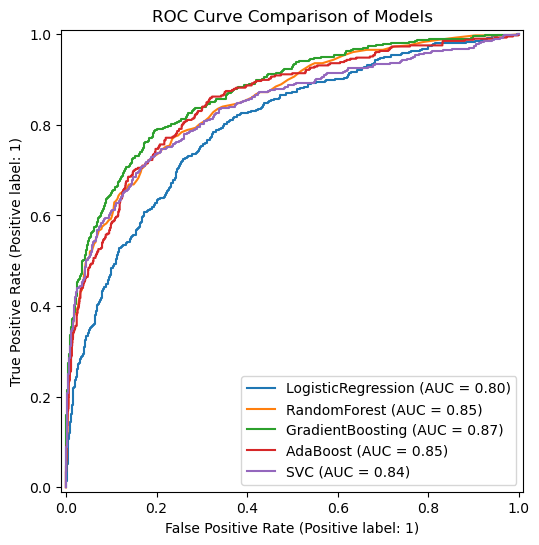

In [20]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob,
        name=name,
        ax=plt.gca()
    )

plt.title('ROC Curve Comparison of Models')
plt.show()

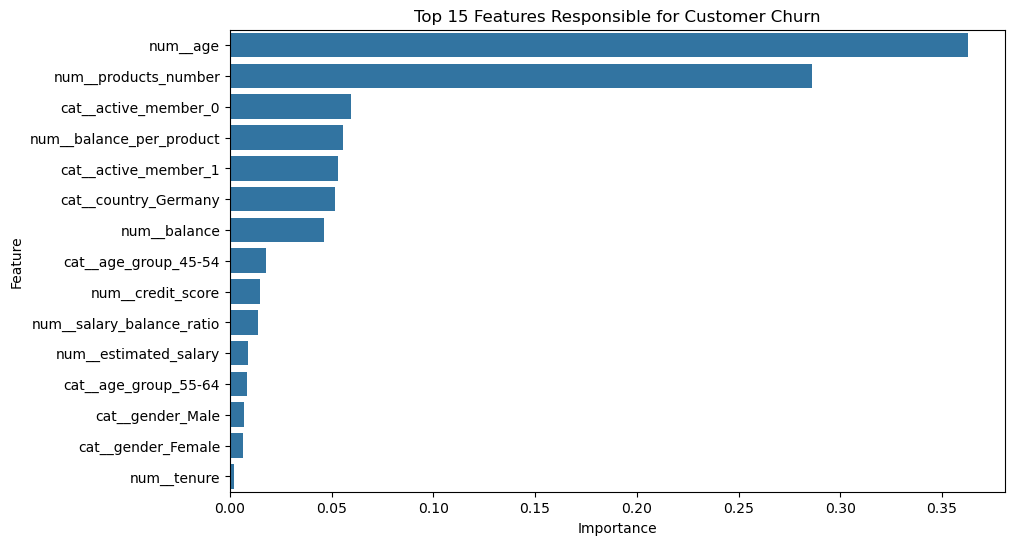

In [21]:
best_pipeline = grid.best_estimator_

feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = best_pipeline.named_steps['classifier'].feature_importances_

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp, x='Importance', y='Feature')
plt.title('Top 15 Features Responsible for Customer Churn')
plt.show()

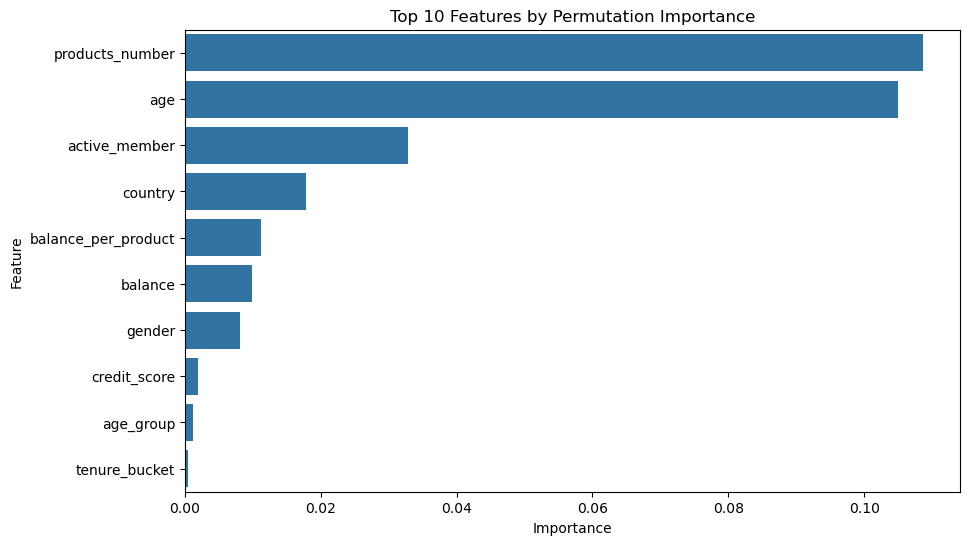

In [22]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

feature_names = X_test.columns

perm_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': result.importances_mean
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=perm_imp, x='Importance', y='Feature')
plt.title('Top 10 Features by Permutation Importance')
plt.show()